# 思路
* 自杀率水平与性别是否有统计上的显著性差异
* 不同年龄组的自杀率是否有显著性差异
* 哪些年龄组的自杀率有显著性差异
* 国家视角
* 自杀率时间做线性回归

# 导入依赖，数据

In [24]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
data = pd.read_csv(r'..\Data\who_suicide_statistics.csv')
print("Data Information")
print(data.info())
print("#" * 50 + "\n" + "Data Description")
print(data.describe())
print("#" * 50 + "\n" + "First Five Rows")
print(data.head())

Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      43776 non-null  object 
 1   year         43776 non-null  int64  
 2   sex          43776 non-null  object 
 3   age          43776 non-null  object 
 4   suicides_no  41520 non-null  float64
 5   population   38316 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 2.0+ MB
None
##################################################
Data Description
               year   suicides_no    population
count  43776.000000  41520.000000  3.831600e+04
mean    1998.502467    193.315390  1.664091e+06
std       10.338711    800.589926  3.647231e+06
min     1979.000000      0.000000  2.590000e+02
25%     1990.000000      1.000000  8.511275e+04
50%     1999.000000     14.000000  3.806550e+05
75%     2007.000000     91.000000  1.305698e+06
max     2016.000000 

In [26]:
# 去缺失值
print(data.isnull().sum())
data = data.dropna()
print(data.head(40))

# 构造自杀率列(百分比)
data['suicide_rate'] = data['suicides_no'] / data['population'] * 100

country           0
year              0
sex               0
age               0
suicides_no    2256
population     5460
dtype: int64
    country  year     sex          age  suicides_no  population
24  Albania  1987  female  15-24 years         14.0    289700.0
25  Albania  1987  female  25-34 years          4.0    257200.0
26  Albania  1987  female  35-54 years          6.0    278800.0
27  Albania  1987  female   5-14 years          0.0    311000.0
28  Albania  1987  female  55-74 years          0.0    144600.0
29  Albania  1987  female    75+ years          1.0     35600.0
30  Albania  1987    male  15-24 years         21.0    312900.0
31  Albania  1987    male  25-34 years          9.0    274300.0
32  Albania  1987    male  35-54 years         16.0    308000.0
33  Albania  1987    male   5-14 years          0.0    338200.0
34  Albania  1987    male  55-74 years          1.0    137500.0
35  Albania  1987    male    75+ years          1.0     21800.0
36  Albania  1988  female  15-24 ye

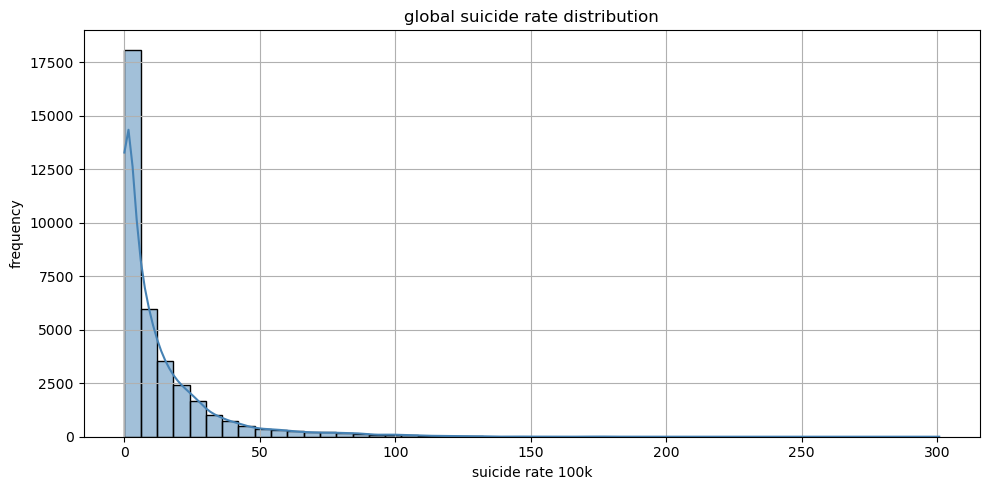

In [45]:
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(data['suicide_rate_100k'], bins=50, kde=True, ax=ax, color='steelblue')
ax.set_xlabel('suicide rate 100k')
ax.set_ylabel('frequency')
ax.set_title('global suicide rate distribution')
plt.tight_layout()
plt.grid()
plt.savefig('../Docs/global_suicide_distribution.png', dpi=300)
plt.show()

# 自杀率与性别的统计推断

In [27]:
# Welch v
def get_df(SX: float, n: float, SY: float, m: float) -> int:
    '''
    返回估计的自由度
    SX为X组的样本标准差，n为该组的样本大小
    SY为Y组的样本标准差，m为该组的样本大小
    '''
    df = ((SX**2/n) + (SY**2/m))**2 / ((SX**2/n)**2/(n-1) + (SY**2/m)**2/(m-1))
    return int(df) if df - int(df) < 0.5 else int(df) + 1

In [28]:
# significance level
a = 0.05

# feature cloumn
female_suicides = data.loc[data['sex'] == 'female', 'suicide_rate']
male_suicides = data.loc[data['sex'] == 'male', 'suicide_rate']

# sample size
female_size = female_suicides.size
male_size = male_suicides.size
print('\n', 'sample size', '\n', '#' * 50)
print(f'Female sample size: {female_size}')
print(f'Male sample size: {male_size}')

# sample mean
female_mean = female_suicides.mean()
male_mean = male_suicides.mean()
print('\n', 'sample mean', '\n', '#' * 50)
print(f'Female sample mean: {female_mean}')
print(f'Male sample mean: {male_mean}')

# sample variance
female_std = female_suicides.var() ** 0.5
male_std = male_suicides.var() ** 0.5
print('\n', 'sample variance', '\n', '#' * 50)
print(f'Female sample standard deviation: {female_std}')
print(f'Male sample standard deviation: {male_std}')

# df
df = get_df(female_std, female_size, male_std, male_size)

# test statistics
mean_diff = female_mean - male_mean
standard_error = (female_std**2 / female_size + male_std**2 / male_size) ** 0.5
t = mean_diff / standard_error

# p-value
p_value = 2 * stats.t.sf(abs(t), df=df)

# result
print('\n', 'Conclusion', '\n', '#' * 50)
if p_value <= a:
    print(f'At significance level a={a}, we can reject the null hypothesis')
else:
    print(f'At significance level a={a}, we fail to reject the null hypothesis')


 sample size 
 ##################################################
Female sample size: 18030
Male sample size: 18030

 sample mean 
 ##################################################
Female sample mean: 0.0057405545984963065
Male sample mean: 0.020629632846979457

 sample variance 
 ##################################################
Female sample standard deviation: 0.008215420181390258
Male sample standard deviation: 0.02477709824032179

 Conclusion 
 ##################################################
At significance level a=0.05, we can reject the null hypothesis


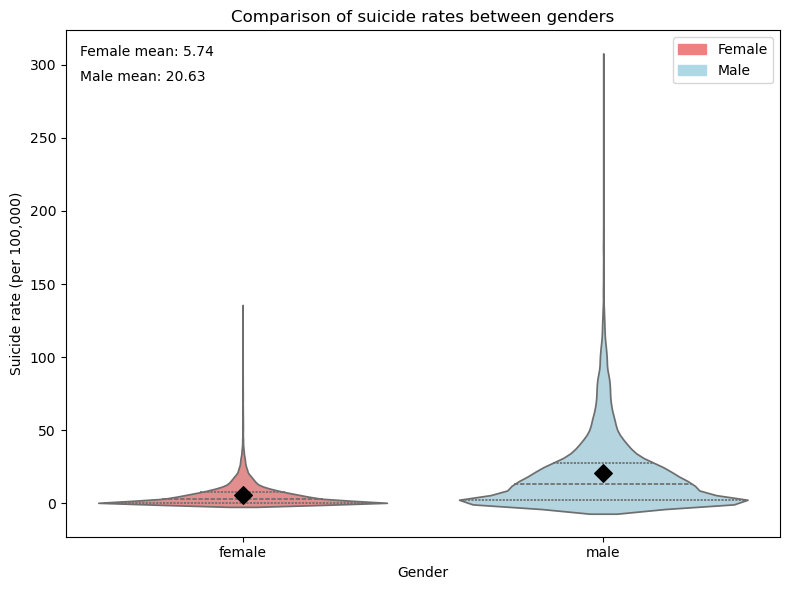

In [49]:
fig, ax = plt.subplots(figsize=(8,6))

# 使用 hue='sex' 并关闭默认图例，消除 FutureWarning
sns.violinplot(x='sex', y='suicide_rate_100k', data=data,
               hue='sex', legend=False,
               inner='quartile', palette=['lightcoral', 'lightblue'], ax=ax)

ax.set_xlabel('Gender')
ax.set_ylabel('Suicide rate (per 100,000)')
ax.set_title('Comparison of suicide rates between genders')

# 自定义图例
import matplotlib.patches as mpatches
female_patch = mpatches.Patch(color='lightcoral', label='Female')
male_patch = mpatches.Patch(color='lightblue', label='Male')
ax.legend(handles=[female_patch, male_patch], loc='upper right')

# 添加均值标记
means = data.groupby('sex')['suicide_rate_100k'].mean()
for i, sex in enumerate(['female', 'male']):
    ax.scatter(i, means[sex], color='black', marker='D', s=80, zorder=10)

# 在图上标注均值数值
ax.text(0.02, 0.95, f'Female mean: {means["female"]:.2f}', transform=ax.transAxes, ha='left', fontsize=10)
ax.text(0.02, 0.90, f'Male mean: {means["male"]:.2f}', transform=ax.transAxes, ha='left', fontsize=10)

plt.tight_layout()
plt.savefig('../Docs/gender.png', dpi=300)
plt.show()

# 自杀率与年龄组的推断


In [29]:
# 年龄组组成
print(data.age.unique())
### 总共六种不同年龄组

['15-24 years' '25-34 years' '35-54 years' '5-14 years' '55-74 years'
 '75+ years']


### ANOVA 假设检验
* levene 检验同方差性
* Jarque-Bera 正态性检验

In [30]:
from scipy.stats import levene

# 按年龄组提取数据
age_groups = [data[data['age'] == g]['suicide_rate'].values for g in data['age'].unique()]

# Levene 检验
stat, p = levene(*age_groups)
print(f"Levene 检验: statistic={stat:.4f}, p={p:.4e}")

if p < 0.05:
    print("结论：方差不齐（异方差）")
else:
    print("结论：方差齐性")

Levene 检验: statistic=1253.2533, p=0.0000e+00
结论：方差不齐（异方差）


In [31]:
from scipy.stats import jarque_bera

age_groups = data['age'].unique()

print("Jarque-Bera 正态性检验（适用于大样本）：")
for age in age_groups:
    group_data = data[data['age'] == age]['suicide_rate']
    stat, p = jarque_bera(group_data)
    print(f"{age}: JB统计量={stat:.4f}, p值={p:.4e}")

Jarque-Bera 正态性检验（适用于大样本）：
15-24 years: JB统计量=21516.3794, p值=0.0000e+00
25-34 years: JB统计量=19238.5368, p值=0.0000e+00
35-54 years: JB统计量=25282.7926, p值=0.0000e+00
5-14 years: JB统计量=1637463.8512, p值=0.0000e+00
55-74 years: JB统计量=9952.0933, p值=0.0000e+00
75+ years: JB统计量=11684.5372, p值=0.0000e+00


### 异方差，不正态分布，但中心极限定理 -> 使用Welch's ANOVA

In [32]:
import pingouin as pg

# 执行 Welch's ANOVA
result = pg.welch_anova(data=data, dv='suicide_rate', between='age')
print(result)

  Source  ddof1         ddof2            F  p_unc       np2
0    age      5  14168.860877  3849.791041    0.0  0.141113


In [33]:
# Games-Howell 事后检验
posthoc = pg.pairwise_gameshowell(data=data, dv='suicide_rate', between='age')
print(posthoc)

              A            B    mean_A    mean_B      diff        se  \
0   15-24 years  25-34 years  0.008808  0.012438 -0.003630  0.000227   
1   15-24 years  35-54 years  0.008808  0.015413 -0.006605  0.000272   
2   15-24 years   5-14 years  0.008808  0.000631  0.008177  0.000126   
3   15-24 years  55-74 years  0.008808  0.016805 -0.007998  0.000277   
4   15-24 years    75+ years  0.008808  0.025016 -0.016209  0.000429   
5   25-34 years  35-54 years  0.012438  0.015413 -0.002975  0.000307   
6   25-34 years   5-14 years  0.012438  0.000631  0.011807  0.000190   
7   25-34 years  55-74 years  0.012438  0.016805 -0.004367  0.000311   
8   25-34 years    75+ years  0.012438  0.025016 -0.012578  0.000452   
9   35-54 years   5-14 years  0.015413  0.000631  0.014782  0.000242   
10  35-54 years  55-74 years  0.015413  0.016805 -0.001392  0.000346   
11  35-54 years    75+ years  0.015413  0.025016 -0.009603  0.000476   
12   5-14 years  55-74 years  0.000631  0.016805 -0.016174  0.00

### 结论：每个年龄组均显著不同，且自杀率随年龄增大而增大

C:\Users\33529\AppData\Local\Temp\ipykernel_27596\1532818214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age', y='suicide_rate_100k', data=data, order=age_order, palette='viridis', ax=ax)


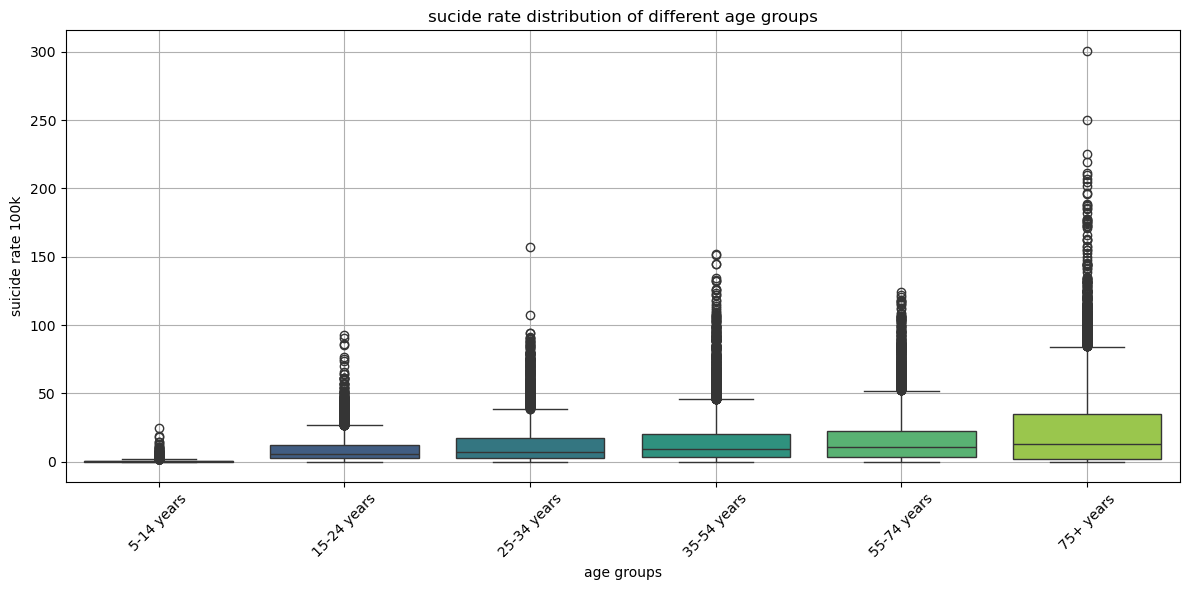

In [57]:
# 计算各年龄组均值（用于标注）
age_means = data.groupby('age')['suicide_rate_100k'].mean().sort_values()
age_order = age_means.index.tolist()

fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(x='age', y='suicide_rate_100k', data=data, order=age_order, palette='viridis', ax=ax)
ax.set_xlabel('age groups')
ax.set_ylabel('suicide rate 100k')
ax.set_title('sucide rate distribution of different age groups')
# 旋转x轴标签
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.savefig('../Docs/age.png', dpi=300)
plt.show()

# 国家视角
### 按国家所属大洲分类，判断不同大洲间的自杀率是否有显著性差异

In [ ]:
# ==================== 完整的国家 -> 大洲 映射字典（更新版） ====================
country_to_continent = {
    # ---------- 亚洲 (Asia) ----------
    'China': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia', 'India': 'Asia',
    'Iran (Islamic Rep of)': 'Asia', 'Israel': 'Asia', 'Jordan': 'Asia',
    'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Kazakhstan': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Armenia': 'Asia',
    'Azerbaijan': 'Asia', 'Bahrain': 'Asia', 'Brunei Darussalam': 'Asia',
    'Cyprus': 'Asia', 'Georgia': 'Asia', 'Hong Kong SAR': 'Asia',
    'Macau': 'Asia', 'Singapore': 'Asia', 'Turkey': 'Asia',
    'Mongolia': 'Asia', 'Oman': 'Asia', 'Philippines': 'Asia', 
    'Qatar': 'Asia', 'Republic of Korea': 'Asia',
    'Sri Lanka': 'Asia', 'Thailand': 'Asia', 'Turkmenistan': 'Asia',
    'United Arab Emirates': 'Asia', 'Uzbekistan': 'Asia',

    # ---------- 欧洲 (Europe) ----------
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe',
    'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe',
    'Bulgaria': 'Europe', 'Croatia': 'Europe', 'Czech Republic': 'Europe',
    'Denmark': 'Europe', 'Estonia': 'Europe', 'Finland': 'Europe',
    'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe',
    'Hungary': 'Europe', 'Iceland': 'Europe', 'Ireland': 'Europe',
    'Italy': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe',
    'Luxembourg': 'Europe', 'Malta': 'Europe', 'Netherlands': 'Europe',
    'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Romania': 'Europe', 'Russia': 'Europe', 'Slovakia': 'Europe',
    'Slovenia': 'Europe', 'Spain': 'Europe', 'Sweden': 'Europe',
    'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',
    'Montenegro': 'Europe', 'Republic of Moldova': 'Europe',
    'Russian Federation': 'Europe', 'San Marino': 'Europe', 'Serbia': 'Europe',
    'TFYR Macedonia': 'Europe',  

    # ---------- 北美洲 (North America) ----------
    'United States': 'North America', 'Canada': 'North America',
    'Mexico': 'North America', 'Costa Rica': 'North America',
    'Cuba': 'North America', 'Dominican Republic': 'North America',
    'El Salvador': 'North America', 'Guatemala': 'North America',
    'Honduras': 'North America', 'Jamaica': 'North America',
    'Nicaragua': 'North America', 'Panama': 'North America',
    'Puerto Rico': 'North America', 'Trinidad and Tobago': 'North America',
    'Bahamas': 'North America', 'Barbados': 'North America',
    'Belize': 'North America', 'Bermuda': 'North America',
    'Antigua and Barbuda': 'North America', 'Aruba': 'North America',
    'Cayman Islands': 'North America', 'Dominica': 'North America',
    'Grenada': 'North America', 'Guadeloupe': 'North America',
    'Martinique': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and Grenadines': 'North America',
    'United States of America': 'North America',
    'Virgin Islands (USA)': 'North America',

    # ---------- 南美洲 (South America) ----------
    'Argentina': 'South America', 'Bolivia': 'South America',
    'Brazil': 'South America', 'Chile': 'South America',
    'Colombia': 'South America', 'Ecuador': 'South America',
    'Guyana': 'South America', 'Paraguay': 'South America',
    'Peru': 'South America', 'Suriname': 'South America',
    'Uruguay': 'South America', 'Venezuela': 'South America',
    'French Guiana': 'South America',
    'Venezuela (Bolivarian Republic of)': 'South America', 

    # ---------- 大洋洲 (Oceania) ----------
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
    'Fiji': 'Oceania', 'Kiribati': 'Oceania',

    # ---------- 非洲 (Africa) ----------
    'Egypt': 'Africa', 'Mauritius': 'Africa', 'Seychelles': 'Africa',
    'South Africa': 'Africa', 'Cabo Verde': 'Africa',
    'Mayotte': 'Africa', 'Reunion': 'Africa',
    'Rodrigues': 'Africa',
    'Sao Tome and Principe': 'Africa',
}

data['continent'] = data['country'].map(country_to_continent)

# 检查剩余未映射的国家
unmapped_remaining = data[data['continent'].isna()]['country'].unique()
print(f"剩余未映射的国家（将被归类为 Other）: {unmapped_remaining}")

# 填充未映射的为 'Other'
data['continent'] = data['continent'].fillna('Other')

# 查看新的分组数量
print("\n更新后各大洲样本量：")
print(data['continent'].value_counts())

剩余未映射的国家（将被归类为 Other）: []

更新后各大洲样本量：
continent
Europe           14388
North America     7752
Asia              7068
South America     4224
Africa            1512
Oceania           1116
Name: count, dtype: int64


In [ ]:
### K-W检验大洲间自杀率差异是否显著
from scipy.stats import kruskal

# 按大洲提取自杀率
continent_groups = [data[data['continent'] == c]['suicide_rate'].values for c in data['continent'].unique()]

# Kruskal-Wallis 检验
h_stat, p_val = kruskal(*continent_groups)
print(f"各大洲之间自杀率差异检验: H={h_stat:.4f}, p={p_val:.4e}")

if p_val < 0.05:
    print("结论：不同大洲的自杀率存在极显著差异 -> 将大洲作为分类变量是合理的")
else:
    print("结论：各大洲无显著差异 -> 不建议作为回归特征")

各大洲之间自杀率差异检验: H=3406.2053, p=0.0000e+00
结论：不同大洲的自杀率存在极显著差异 -> 将大洲作为分类变量是合理的


In [40]:
import pingouin as pg

# 1. Welch's ANOVA（检验各大洲均值是否显著不同）
welch_continent = pg.welch_anova(data=data, dv='suicide_rate', between='continent')
print("=== 各大洲 Welch's ANOVA 结果 ===")
print(welch_continent)
print("\n" + "="*50 + "\n")

# 2. Games-Howell 事后检验（两两比较，找出哪些大洲之间有差异）
posthoc_continent = pg.pairwise_gameshowell(data=data, dv='suicide_rate', between='continent')
print("=== 各大洲 Games-Howell 两两比较结果 ===")
print(posthoc_continent)

=== 各大洲 Welch's ANOVA 结果 ===
      Source  ddof1        ddof2           F  p_unc       np2
0  continent      5  6733.899845  461.478019    0.0  0.057004


=== 各大洲 Games-Howell 两两比较结果 ===
                A              B    mean_A    mean_B      diff        se  \
0          Africa           Asia  0.006663  0.011506 -0.004844  0.000393   
1          Africa         Europe  0.006663  0.018676 -0.012013  0.000386   
2          Africa  North America  0.006663  0.007274 -0.000611  0.000358   
3          Africa        Oceania  0.006663  0.011811 -0.005148  0.000482   
4          Africa  South America  0.006663  0.010838 -0.004175  0.000408   
5            Asia         Europe  0.011506  0.018676 -0.007169  0.000296   
6            Asia  North America  0.011506  0.007274  0.004232  0.000258   
7            Asia        Oceania  0.011506  0.011811 -0.000304  0.000413   
8            Asia  South America  0.011506  0.010838  0.000669  0.000324   
9          Europe  North America  0.018676  0.007274 

世界地图数据的列名：
['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_

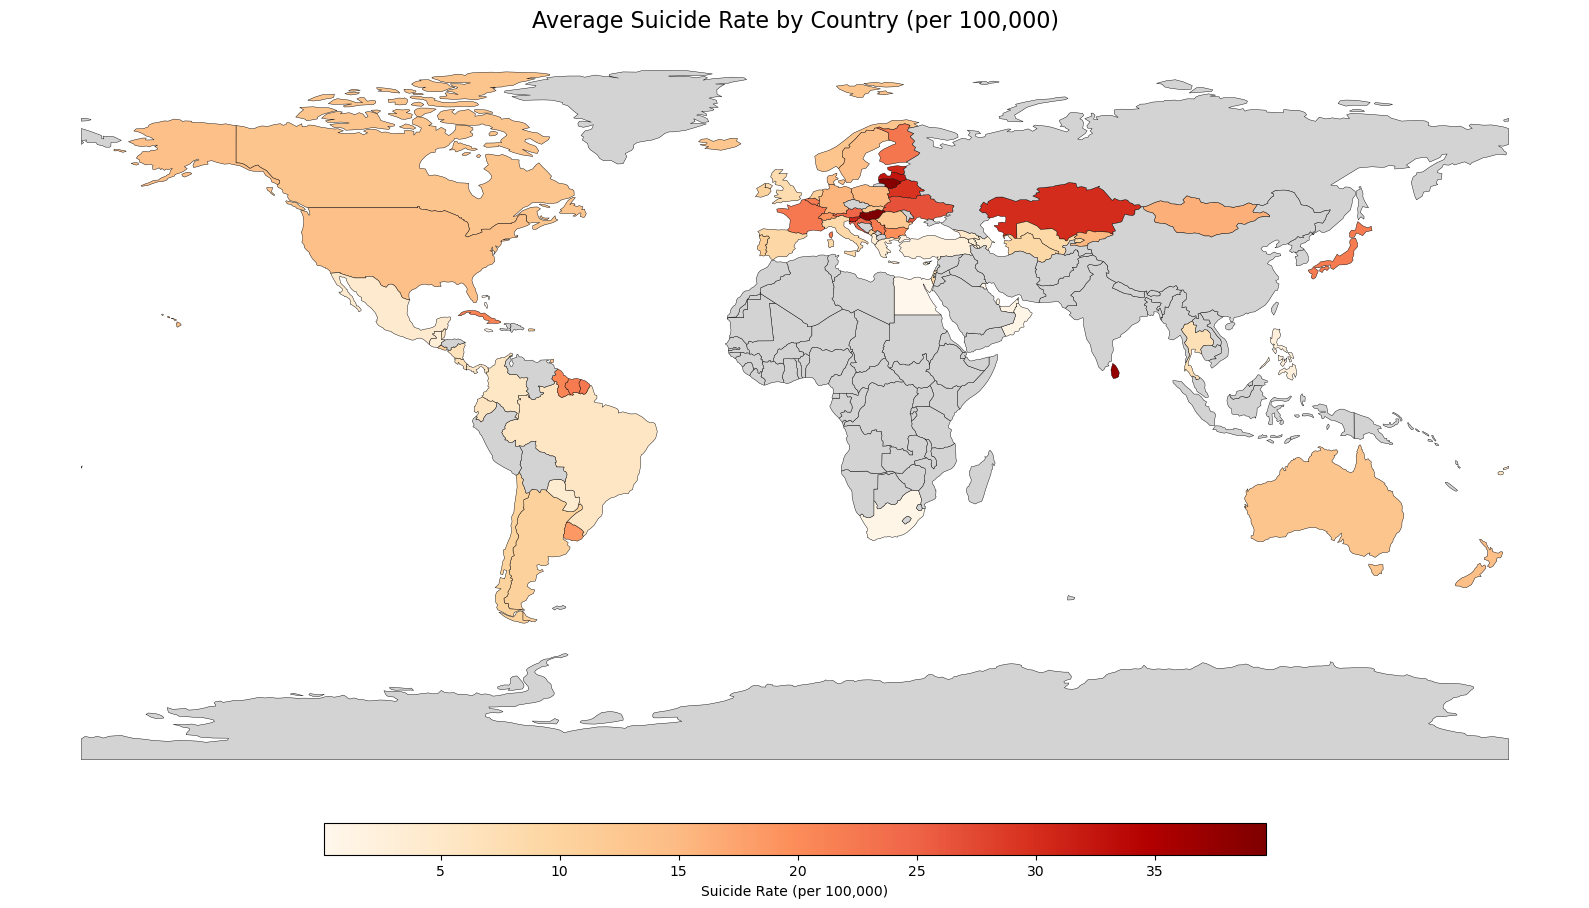

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. 读取世界地图
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# 2. 打印所有列名，看看有哪些列
print("世界地图数据的列名：")
print(world.columns.tolist())

# 3. 自动查找国家名称列（常见的几种命名）
possible_name_cols = ['name', 'NAME', 'name_long', 'admin', 'ADMIN', 'sovereignt']
name_col = None
for col in possible_name_cols:
    if col in world.columns:
        name_col = col
        break

if name_col is None:
    # 如果找不到，就使用第一列（通常第一个非几何列是名称）
    # 但更稳健：直接让用户指定
    raise ValueError("无法自动识别国家名称列，请查看上面打印的列名，手动设置 name_col 变量。")

print(f"将使用列 '{name_col}' 作为国家名称进行合并")

# 4. 按国家计算平均自杀率
country_agg = data.groupby('country')['suicide_rate_100k'].mean().reset_index()

# 5. 合并数据（左连接保留所有国家）
world_merged = world.merge(country_agg, left_on=name_col, right_on='country', how='left')

# 6. 绘制世界地图
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

world_merged.plot(column='suicide_rate_100k',
                  ax=ax,
                  legend=True,
                  legend_kwds={
                      'label': 'Suicide Rate (per 100,000)',
                      'orientation': 'horizontal',
                      'shrink': 0.6,
                      'pad': 0.03,
                      'aspect': 30
                  },
                  cmap='OrRd',
                  edgecolor='black',
                  linewidth=0.3,
                  missing_kwds={'color': 'lightgray', 'label': 'No data'}
                 )

ax.set_title('Average Suicide Rate by Country (per 100,000)', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.savefig('../Docs/world_map.png', dpi=300)
plt.show()

# 多元线性回归

新特征描述：
    year  year_centered  suicide_rate  suicide_rate_100k
24  1987              0      0.004833           4.832585
25  1987              0      0.001555           1.555210
26  1987              0      0.002152           2.152080
27  1987              0      0.000000           0.000000
28  1987              0      0.000000           0.000000

多元线性回归结果（因变量：每10万人自杀率）
                            OLS Regression Results                            
Dep. Variable:      suicide_rate_100k   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     25.73
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           2.30e-27
Time:                        09:41:23   Log-Likelihood:            -1.5145e+05
No. Observations:               36060   AIC:                         3.029e+05
Df Residuals:                   36047   BIC:                         3.030

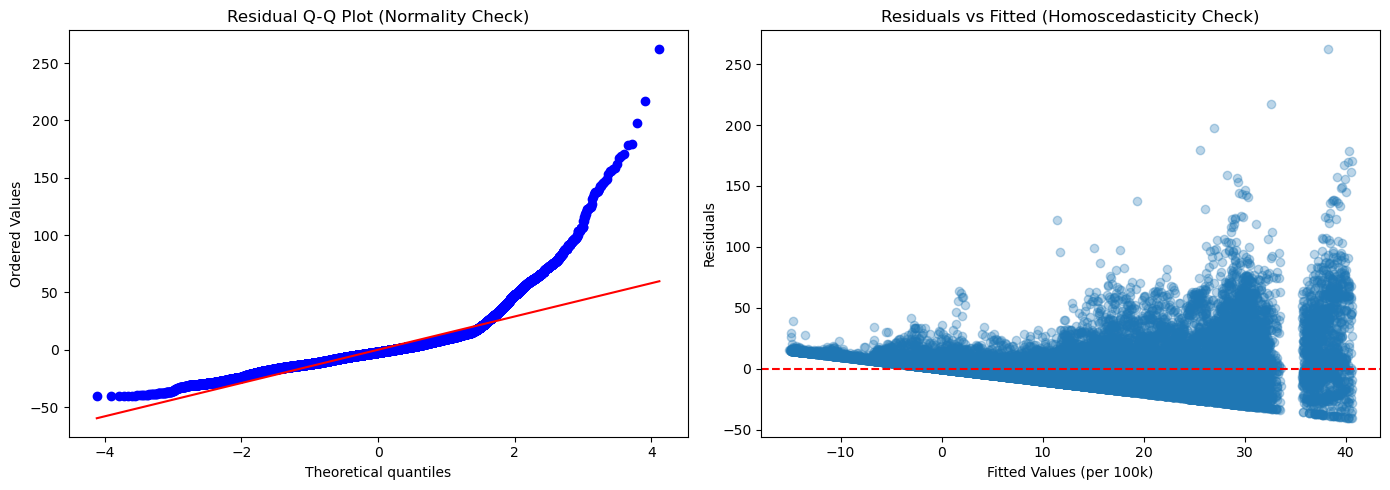


Breusch-Pagan 异方差检验: LM=2926.2284, p=0.0000e+00
提示：存在异方差（但我们已经使用了聚类稳健标准误，系数估计依然有效）


In [41]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np

# ================== 1. 特征工程 ==================
# 年份中心化（以1987年为基准年，让截距有意义）
data['year_centered'] = data['year'] - 1987

# 创建标准自杀率（每10万人），便于系数解读
data['suicide_rate_100k'] = data['suicide_rate'] * 1000  # 因为 rate 原本是 *100，再乘1000 = 每10万

# 检查一下新生成的列
print("新特征描述：")
print(data[['year', 'year_centered', 'suicide_rate', 'suicide_rate_100k']].head())

# ================== 2. 拟合多元线性回归（使用公式API） ==================
# C(sex) 和 C(age) 和 C(continent) 会自动生成虚拟变量，无需手动编码
model = smf.ols('suicide_rate_100k ~ year_centered + C(sex) + C(age) + C(continent)', data=data).fit()

# 按国家聚类调整标准误（处理组内相关性）
model_robust = model.get_robustcov_results(cov_type='cluster', groups=data['country'])

# ================== 3. 打印回归结果 ==================
print("\n" + "="*60)
print("多元线性回归结果（因变量：每10万人自杀率）")
print("="*60)
print(model_robust.summary())

# ================== 4. 模型诊断（放几张图进报告） ==================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：残差 Q-Q 图（检验正态性）
stats.probplot(model.resid, dist="norm", plot=axes[0])
axes[0].set_title('Residual Q-Q Plot (Normality Check)')

# 图2：残差 vs 拟合值（检验异方差）
axes[1].scatter(model.fittedvalues, model.resid, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Fitted Values (per 100k)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted (Homoscedasticity Check)')

plt.tight_layout()
plt.show()

# ================== 5. （可选）Breusch-Pagan 异方差检验 ==================
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"\nBreusch-Pagan 异方差检验: LM={bp_test[0]:.4f}, p={bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("提示：存在异方差（但我们已经使用了聚类稳健标准误，系数估计依然有效）")
else:
    print("提示：未检测到明显异方差")